## Кратко в предыдущих сериях

Советуем перед семинаром освежить в памяти из курса статистики:

* Описательные статистики: среднее, частота абсолютная и относительная, выборочные медиана и квантили, их поиск с помощью пакета `numpy`
* ЦПТ
* Точечные и интервальные оценки
* Оценки параметров среднего и пропорции
* Визуализации с помощью `matplotlib` и `seaborn`
* Работа с датасетами в `pandas`

# Тема 3. Хорошая метрика. Кто она?

## 0. Цель и задачи

**Цель** — разобраться, как выбрать метрику под конкретную задачу

**Задачи:** 

- повторить, какие есть основные свойства метрик
- посмотреть на практике на некоторые свойства метрик
- узнать, бывают ли идеальные метрики
- потренироваться с выбором метрики под конкретный случай

## 1. Предисловие

### 1.1. Вспомним лекцию

Какие свойства метрик вы изучали на лекции?

- ***Чувствительность*** — метрика быстро и заметно реагирует на изменения в продукте или поведении пользователей
- ***Достоверность*** — Можем ли мы доверять данным, на которых собирается метрика? Есть ли смещение? Нет ли ошибки выжившего?
- ***Эффективность расчета*** — Выгодно ли рассчитывать метрику? Принесет ли она больше пользы, чем потратим на ее подсчет?
- ***Отлаживаемость*** — Можем ли мы понять причины изменения метрики?
- ***Интерпретируемость*** — Понятно, изменение метрики это хорошо или плохо? Понятно, какие решения принимают, когда увидят изменение метрики? Можем объяснить метрику бизнесу?

### 1.2. ✍️Практика: по каждому пункту приведем примеры


По каждому из пунктов давайте приведем примеры и антипримеры таких метрик

- Чувствительность:
    - пример: метрики посещаемости (DAU, MAU, etc) — зачастую даже за небольшой промежуток времени видна серьезная разница
    - антипример: средний чек — очень подвержен выбросам, сложно повышать путем каких-то изменений
- Достоверность:
    - пример: метрики скорости работы сайта — собираются автоматически, полные, редко происходят сбои в сборе
    - антипример: NPS / CSAT — зачастую добровольный, поэтому малое покрытие и нерепрезентативная выборка (отвечают в основном либо "промоутеры", либо "критики")
- Эффективность расчета:
    - пример: метрики скорости работы сайта — собираются автоматически, нужно лишь однократно настроить логику сборки, а пользы могут принести очень много
    - антипример: сбор NPS / CSAT каждый день — посчитайте лишь, сколько времени занимает сбор этой информации и переведите в деньги
- Отлаживаемость:
    - пример: метрики удержания — хорошие изменения $\rightarrow$ сохраненный клиент
    - антипример: метрики посещаемости — на них влияет все: и сезонность, и случайный рост продукта, часто непонятно, отчего произошли изменения
- Интерпретируемость:
    - пример: конверсия в покупку — много покупают = хорошо
    - антипример: кол-во шагов для покупки — не всегда понятно, много — это хорошо (заинтересованность, подробное изучение) или плохо (сложный UX)


**Вот таблица по основным метрикам и их характеристикам:**

| Метрика                                            | Чувствительность                                          | Достоверность                                         | Отлаживаемость                                           | Интерпретируемость                                 |
| -------------------------------------------------- | -------------------------------------------------------- | -------------------------------------------------- | -------------------------------------------------------- | -------------------------------------------------- |
| Метрики посещаемости                               | <span style="color:indigo">Зачастую высокая</span> — часто довольно легко повлиять даже за небольшой промежуток времени                                                         | <span style="color:indigo">Зачастую высокая</span>, но может быть фрод / дубликаты                            | <span style="color:red">Низкая</span> — рост может быть связан с чем угодно: маркетинг, сезон, случайность    | <span style="color:green">Высокая</span> — все понимают, что рост это хорошо                                 |
| Метрики удержания                                  | <span style="color:gold">Средняя</span> — чувствительна к UX-изменениям, но сложно с замером роста на маленьких данных                                                  | <span style="color:indigo">Зачастую высокая</span>, но могут быть пропуски при неполной сборке событий        | <span style="color:green">Высокая</span> — можно строить анализ когорт, кривые ретеншна и понимать, за счет чего происходят изменения                            | <span style="color:gold">Средняя</span> — не всегда очевидно, почему удержание падает и как это связано с продуктом                                                 |
| Конверсия в регистрацию                            | <span style="color:gold">Средняя</span> — чувствительна к UX-изменениям, но сложно с замером роста на маленьких данных                                                 | <span style="color:indigo">Зачастую высокая</span>, но может быть фрод / дубликаты                            | <span style="color:green">Высокая</span> — можно смотреть по шагам воронки                                   | <span style="color:green">Высокая</span> — легко объяснить влияние изменений UI/UX                            |
| Конверсия в оплату                                 | <span style="color:gold">Средняя</span> — часто довольно маленькие значения, поэтому сложно заметить изменения| <span style="color:gold">Средняя</span> — страдает от узкой выборки (только активные клиенты)              | <span style="color:gold">Средняя</span> — не всегда ясно, что влияет: высокая/низкая цена, user-friendly/ not friendly интерфейс                                   | <span style="color:green">Высокая</span> — оплатили = хорошо                                                  |
| Средний чек (ARPU)                                 | <span style="color:red">Низкая</span> — чувствительна к выбросам и малому числу плательщиков                 | <span style="color:gold">Средняя</span> — могут искажать скидки, возвраты, ошибки, плюс смотрит только на платящих (ошибка выжившего)                                    | <span style="color:red">Низкая</span> — тяжело объяснить рост: больше покупок или товар подорожал?            | <span style="color:gold">Средняя</span> — мало показывает без кол-ва покупок, очень важно смотреть динамику   |
| Кол-во багов/жалоб                                 | <span style="color:green">Высокая</span> — исправили баг, и жалуются обычно меньше 😄                     | <span style="color:red">Низкая</span> — зависит от того, кто жалуется, и как фиксируются баги                 | <span style="color:green">Высокая</span> — можно группировать по типам ошибок, продуктам              | <span style="color:gold">Средняя</span> — жалоб много, это плохо, но может быть, мало жалоб = равнодушие к продукту                                                   |
| NPS / CSAT                                         | <span style="color:red">Низкая</span> — инертна, чувствительна к формулировке вопросов, может быть малое число респондентов                                     | <span style="color:red">Низкая</span> — зачастую добровольный, поэтому малое покрытие и нерепрезентативная выборка (ошибка выжившего)                           | <span style="color:red">Низкая</span> — не всегда понятно, что повлияло: уменьшение цены? улучшение продукта/сервиса?                                             | <span style="color:gold">Средняя</span> — бизнес любит, но сложно связать с бизнес-ценностью                 |
| Кол-во просмотренных экранов / шагов               | <span style="color:gold">Средняя</span> — зависит от продукта                                             | <span style="color:indigo">Зачастую высокая</span>, но могут быть пропуски при неполной сборке событий      | <span style="color:gold">Средняя</span> — плохо декомпозируется, так как уже низкоуровневая          | <span style="color:red">Низкая</span> — не всегда понятно, много — это хорошо (заинтересованность, подробное изучение) или плохо (сложный UX)                     |
| Метрики загрузки / скорости                        | <span style="color:indigo">Зачастую высокая</span> — даже небольшие задержки заметны, но смотрим не среднее, а перцентиль (имеет довольно тяжелые хвосты)           | <span style="color:green">Высокая</span> — собираются автоматически, полные, редко происходят сбои в сборе   | <span style="color:green">Высокая</span> — легко найти виновника: сервер, сеть, клиент                       | <span style="color:gold">Средняя</span> — бизнесу понятно: быстрее = лучше, но не всегда быстрая загрузка = профит                                               |

## 2. Закрепим на примерах

***Давайте потренеруемся работать с некоторыми свойствами метрик на практике***

In [2]:
import matplotlib.pyplot as plt
import scipy.stats as sps
from scipy.stats import zscore
import numpy as np
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm
from statsmodels.tsa.seasonal import STL, seasonal_decompose
import os
from pylab import rcParams
from sklearn.linear_model import LinearRegression

sns.set_theme(style='whitegrid')
sns.set(palette="Set2", font_scale=1)

### 2.1 Чувствительность

Начнем с чувствительности. 

#### ✍️ Интерактив: как можно оценить чувствительность?

Студенты предлагают, что можно сделать. Самые логичные ответы — посмотреть длину дов. интервалов или, если у студентов высокий уровень, провести аб-тест на истории и оценить мощность (последнее — будем делать позже, а далее в семинаре будет первый решение по первому ответу).

> **Типовой ответ:** 
— Gосмотреть длину дов. интервалов. Если у метрики широкий интервал, значит, на эксперименте, скорее всего, мы не заметим изменения.
— Широкий в абсолютных или относительных значениях? 
— В относительных. Например, у конверсии в просмотр товара конверсия $0.6 \pm 0.02$, а у конверсии в покупку конверсия $0.05 \pm 0.01.$ Очевидно, что конверсию в просмотр квеличить на 2 п.п. легче, чем конверсию в покупку на 1 п.п.

In [3]:
rng = np.random.default_rng(42)

# Parameters
N_USERS = 100_000
# Generate number of sessions per user (min 1)
sessions_per_user = rng.poisson(lam=5, size=N_USERS) + 1

records = []
session_counter = 0

for user_id, n_sessions in enumerate(sessions_per_user, start=1):
    # draw per-user baseline probabilities for more heterogeneity
    base_view_p = rng.uniform(0.25, 0.9)
    base_cart_p = rng.uniform(0.15, 0.6)
    base_purchase_p = rng.uniform(0.05, 0.35)

    for _ in range(n_sessions):
        session_counter += 1

        viewed = rng.random() < base_view_p
        added = rng.random() < (base_cart_p if viewed else 0)
        purchased = rng.random() < (base_purchase_p if added else 0)

        spend = 0.0
        if purchased:
            spend = rng.gamma(shape=3, scale=700)  # mean ~40
            # introduce 0.5% outliers – big spenders
            if rng.random() < 0.015:
                spend *= 25  # huge order

        records.append(
            (user_id, session_counter, viewed, added, purchased, round(spend, 2))
        )

df = pd.DataFrame(
    records,
    columns=["user_id", "session_id", "viewed", "added", "purchased", "spend"],
)

def assign_csat(row):
    # Base 5 % chance to answer survey
    prob_answer = 0.05
    if row['purchased']:
        prob_answer = 0.40  # buyers are far likelier to respond
    elif row['viewed']:
        prob_answer = 0.08

    answered = rng.random() < prob_answer
    if not answered:
        return pd.Series({"csat_answered": False, "csat_score": np.nan})

    # Score distribution also (mildly) correlated with funnel success
    mean_score = 4.2 if row.purchased else (3.5 if row.viewed else 3.0)
    score = np.clip(rng.normal(loc=mean_score, scale=0.8), 1, 5)
    return pd.Series({"csat_answered": True, "csat_score": round(score, 1)})


df[["csat_answered", "csat_score"]] = df.apply(assign_csat, axis=1)

df

,user_id,session_id,viewed,added,purchased,spend,csat_answered,csat_score
0,1,1,True,False,False,0.00,False,NaN
1,1,2,False,False,False,0.00,False,NaN
2,1,3,True,False,False,0.00,False,NaN
3,1,4,False,False,False,0.00,False,NaN
4,1,5,True,True,True,681.11,False,NaN
...,...,...,...,...,...,...,...,...
599477,100000,599478,True,True,True,1479.92,False,NaN
599478,100000,599479,True,True,False,0.00,False,NaN
599479,100000,599480,True,False,False,0.00,False,NaN
599480,100000,599481,True,False,False,0.00,True,4.3


In [4]:
df.to_csv('market.csv', index=False)

Рассмотрим датасет с сессиями в интернет-магазине за некоторое время. 

Приведем небольшое описание колонок датасета:

### 📄 Описание колонок в сгенерированном датасете

| Название         | Описание                                                                 |
|------------------|--------------------------------------------------------------------------|
| `user_id`        | ID пользователя (уникален на уровне пользователя)                        |
| `session_id`     | ID сессии (уникален глобально)                                           |
| `viewed`         | Флаг (bool), был ли просмотр хотя бы одного товара в сессии              |
| `added`          | Флаг (bool), был ли добавлен хотя бы один товар в корзину                |
| `purchased`      | Флаг (bool), была ли совершена покупка в этой сессии                     |
| `spend`          | Сумма покупки в рублях (0, если не было покупки)|
| `csat_answered`  | Флаг (bool), был ли заполнен CSAT-опрос по итогам сессии                 |
| `csat_score`     | Оценка удовлетворенности (от 1.0 до 5.0), если пользователь ответил. Иначе — NaN |

**Посмотрим на данные**

In [5]:
df = pd.read_csv('market.csv')
df

#### ✍️ Интерактив. Какие метрики будем сравнивать?

Студенты предлагают метрики, которые можно сравнить. Лучше всего сравнить конверсию в покупку и средний чек (среди купивших.)

Возьмем функции из предыдущего семинара по бутстрепу

> Напомним, что мы не можем рассматривать сессии как независимые события, так как у одного пользователя могут быть несколько, вообще говоря, зависимых между собой сессий. Именно поэтому важно в бутстрепе учесть сэмплирование по пользователям.

In [7]:
def count_bootstrap_statistics(data, target_col, boot_fn, stat_fn, n_boot=10_000):
    '''
    Подсчет бутстрепных статистик методом подстановки

    Параметры:
        data -- датафрейм с выборкой
        target_col -- колонка с интересующей нас метрикой
        boot_fn -- функция, реализующая бутстреп
        stat_fn -- функция, считающая статистику
        n_boot -- кол-во запусков бутстрепа

    Возвращает:
        boot_stat -- массив бутстрепных статистик
    '''

    boot_stat = []
    for _ in tqdm(range(n_boot)):
        # бутстрепим данные
        data_boot = boot_fn(data, target_col)
        # считаем бутстрепную статистику и добавляем ее в массив
        boot_stat.append(stat_fn(data_boot))

    return boot_stat

In [8]:
def bootstrap_users(data, target_col, user_col='customer_id'):
    """
    Делает одну бутстрепную выборку пользователей и возвращает все их заказы.
    
    Параметры:
        data -- датафрейм с выборкой
        target_col -- колонка с интересующей нас метрикой        
        user_col -- колонка с идентификатором пользователя.
        
    Возвращает:
        boot_data —- новый датафрейм с бутстреп-выборкой заказов.
    """

    # Получаем список уникальных пользователей
    unique_users = data[user_col].unique()

    # Бутстрепим пользователей с возвращением
    sampled_users = np.random.choice(unique_users, size=len(unique_users), replace=True)

    # Собираем все заказы выбранных пользователей
    boot_data = data[data[user_col].isin(sampled_users)].copy()

    # Добавим, сколько раз каждый пользователь попал в выборку (важно для повторов)
    user_counts = pd.Series(sampled_users).value_counts()
    
    # Повторим строки в соответствии с количеством выборов пользователя
    boot_data = boot_data.merge(user_counts.rename("replications"), left_on=user_col, right_index=True)
    boot_data = boot_data.loc[boot_data.index.repeat(boot_data['replications'])][target_col]

    return boot_data

Напишем функцию для визуализации доверительных интервалов

In [10]:
def count_conf_ints(df, target_col, user_col, name_metric, alpha=0.95, n_boot=10_000):
    """
    Строит и сравнивает классический и бутстрэп-доверительные интервалы (ДИ) 
    для среднего значения метрики. Визуализирует распределение бутстрэпных средних 
    и длину интервалов.

    Параметры
    ----------
    df : pandas.DataFrame
        Датасет
    
    target_col : str
        Название колонки с метрикой метрики
    
    alpha : float, optional (по умолчанию = 0.95)
        Уровень доверия для построения интервалов (например, 0.95 — это 95% ДИ)
    
    n_boot : int, optional (по умолчанию = 10_000)
        Количество итераций бутстрэпа
    
    precision : int, optional (по умолчанию = 0)
        Количество знаков после запятой при округлении значений для вывода

    Вывод
    -----
    На экран печатается:
    - Среднее значение метрики
    - Бутстрэп-доверительный интервал
    - Относительная длина дов. интервала (в долях от среднего значения)

    Также строится гистограмма распределения бутстрэпных средних значений
    с визуализацией границ обоих интервалов.

    Примечания
    ----------
    - Классический ДИ основан на t-распределении с оценкой стандартной ошибки.
    - Бутстрэп-интервал строится по квантилям распределения бутстрэпных средних.
    - Используется визуализация на matplotlib для наглядного сравнения.

    Возвращает
    ----------
    None
    """
    # --- Среднее --- 
    mean = df[target_col].mean()
    
    # --- Бутстрэп ДИ ---
    bootstrap_means = count_bootstrap_statistics(
        df, target_col=target_col, stat_fn=np.mean, n_boot=n_boot,
        boot_fn=lambda df, target_col: bootstrap_users(df, target_col, 
                                                       user_col=user_col))
    ci = (np.quantile(bootstrap_means, (1 - alpha) / 2),
          np.quantile(bootstrap_means, (1 + alpha) / 2))
    

    # --- Вывод ---
    print(f"Среднее по метрике {name_metric}: {mean:.4f}")
    print(f"Бутстрэп 95% ДИ:     ({ci[0]:.4f}, {ci[1]:.4f})")
    print(f"Относительная длина бутстрепного ДИ: {((ci[1] - ci[0]) / mean):.3f}")


    # --- Визуализация ---
    plt.figure(figsize=(10, 6))
    plt.hist(bootstrap_means, bins=50, color='skyblue', edgecolor='black', alpha=0.7,
        density=True)
    plt.axvline(mean, color='blue', linestyle='--', label=f'Среднее: {mean:.3f}')
    plt.axvline(ci[0], color='red', linestyle='--', 
                label=f'Бутстрэп {int(100 * alpha)}% ДИ')
    plt.axvline(ci[1], color='red', linestyle='--')
    plt.title(f"Доверительный интервал среднего метрики {name_metric}")
    plt.xlabel("Среднее значение (из бутстрэп-выборок)")
    plt.ylabel("Частота")
    plt.legend()
    plt.grid(True)
    plt.show()
    return

Посчитаем и визуализируем дов. интервалы для конверсии в покупку.

  0%|          | 0/10000 [00:00<?, ?it/s]

Среднее по метрике конверсия в покупку: 0.0430
Бутстрэп 95% ДИ:     (0.0424, 0.0435)
Относительная длина бутстрепного ДИ: 0.025


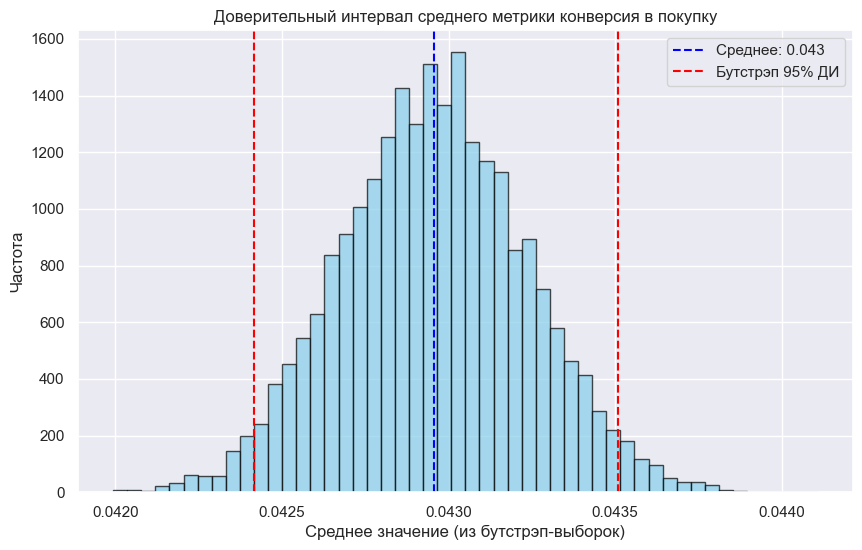

In [11]:
count_conf_ints(df, 'purchased', 'user_id', 'конверсия в покупку', n_boot=10_000)

Посчитаем и визуализируем дов. интервалы для среднего чека.

  0%|          | 0/10000 [00:00<?, ?it/s]

Среднее по метрике средний чек: 2922.4071
Бутстрэп 95% ДИ:     (2829.7781, 3019.3450)
Относительная длина бутстрепного ДИ: 0.065


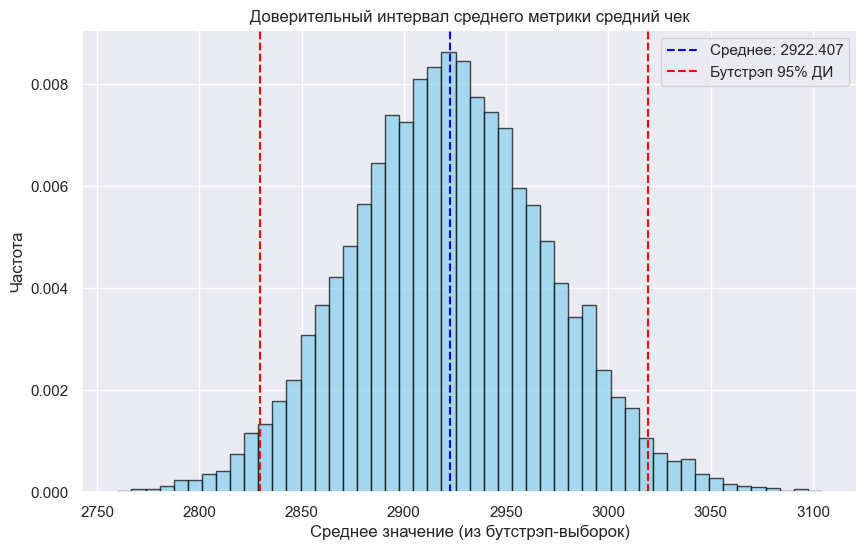

In [12]:
df_purchased = df[df['purchased']]
count_conf_ints(df_purchased, 'spend', 'user_id', 'средний чек', n_boot=10_000)

<Axes: >

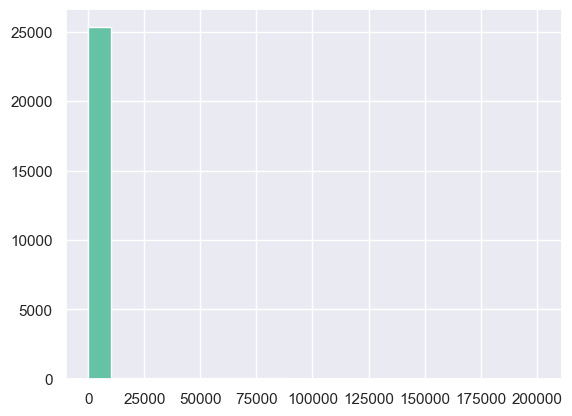

In [15]:
df_purchased['spend'].hist(bins=20)

In [16]:
df_purchased['spend'].max()

201100.32

In [19]:
df_purchased['spend'].median(), df_purchased['spend'].mean()

(1898.75, 2922.4071337035457)

In [20]:
df_purchased['spend'].quantile(0.95)

4778.54

<Axes: >

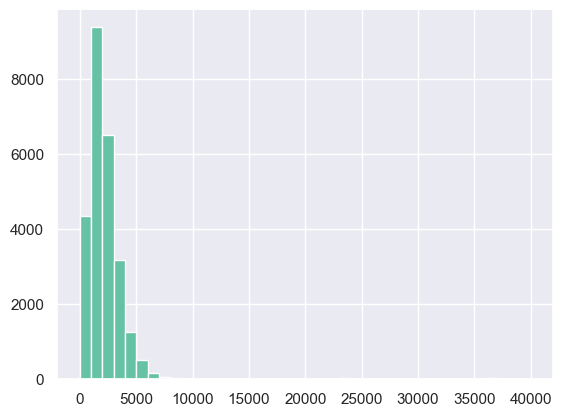

In [18]:
df_purchased['spend'].hist(bins=np.linspace(0, 40_000, 41))

**Вывод:** в данном примере более чувствительным оказалась конверсия в покупку: длина ее доверительного интервала 2.5% против 6.5% у среднего чека. Это произошло в основном из-за двух моментов:
- у среднего чека меньше наблюдений: средняя конверсия в покупку 4.3%, что при 600 тыс. сессиях дает нам около 25 тыс. покупок, что значительно меньше 600 тыс. наблюдений конверсий в покупку
- у среднего чека есть выбросы: при медиане 2 тыс. ₽ и среднем меньше 3 тыс. ₽ встречается значение более 200 тыс. ₽, при этом 95% чеков меньше 5 тыс. ₽

### 2.2 Достоверность

#### ✍️ Интерактив: что можно проверить на данных из достоверности?


Из достоверности на данных можно проверить несколько вещей:
- можем ли мы доверять данные — посмотреть Sanity Check из семинара 2
- есть ли смещение/ошибка выжившего? — это мы и будем смотреть на примере

Посмотрим на средний CSAT по всем, по купившим и по просмотревшим

In [21]:
df_purchased = df[df['purchased']]
df_viewed = df[df['viewed']]

csat = df['csat_score'].mean()
csat_purchased = df_purchased['csat_score'].mean()
csat_viewed = df_viewed['csat_score'].mean()

print(f'''средний ксат по всей выборке: {csat:.2f}''')
print(f'''средний ксат по купившим: {csat_purchased:.2f}''')
print(f'''средний ксат по просмотревшим: {csat_viewed:.2f}''')

средний ксат по всей выборке: 3.50
средний ксат по купившим: 4.15
средний ксат по просмотревшим: 3.68


Посмотрим также на покрытие CSAT по этим же сегментам

In [22]:
csat_frac = df['csat_answered'].sum() / len(df)
csat_frac_purchased = df_purchased['csat_answered'].sum() / len(df_purchased)
csat_frac_viewed = df_viewed['csat_answered'].sum() / len(df_viewed)

print(f'''покрытие ксат по всей выборке: {csat_frac:.3f}''')
print(f'''покрытие ксат по купившим: {csat_frac_purchased:.3f}''')
print(f'''покрытие ксат по просмотревшим: {csat_frac_viewed:.3f}''')

покрытие ксат по всей выборке: 0.081
покрытие ксат по купившим: 0.396
покрытие ксат по просмотревшим: 0.104


Видим значительный перекос в сторону тех, кто покупает товар

> Если мы хотим оценить ксат по товарам, то в таком случае можно смотреть только ксат по купившим, и никакой проблемы не будет. А вот если мы хотим смотреть, например, ксат по сайту, то в таком случае лучше смотреть ксат по всем, причем перевзвешенный с весами долей сегментов.

In [23]:
df_not_viewed = df[~df['viewed']]
df_viewed_not_purchased = df[(df['viewed']) & (df['purchased'])]
df_purchased = df[df['purchased']]


csat_not_viewed = df_not_viewed['csat_score'].mean()
csat_viewed_not_purchased = df_viewed_not_purchased['csat_score'].mean()
csat_purchased = df_purchased['csat_score'].mean()

frac_not_viewed = len(df_not_viewed) / len(df)
frac_viewed_not_purchased = len(df_viewed_not_purchased) / len(df)
frac_purchased = len(df_purchased) / len(df)

In [24]:
csats = [csat_not_viewed, csat_viewed_not_purchased, csat_purchased]
weights = [frac_not_viewed, frac_viewed_not_purchased, frac_purchased]

csat_right = np.average(csats, weights=weights)
print(f'''перевзвешенный ксат по просмотревшим: {csat_right:.2f}''')

перевзвешенный ксат по просмотревшим: 3.19


**Вывод:** мы встретили ошибку выжившего в данных CSAT: посчитали среднюю оценку, оценку по группам и перевзвешенную оценку с весами сегментов, которая значительно отличается от изначального среднего. Это значит, что данные по CSAT нельзя считать достоверными: у них есть явное смещение.[

### 2.3 Эффективность расчета

***Вопрос в зал:*** можем ли мы проверить эффективность расчета на данных? — Нет, это нужно экономически обосновывать стоимость расчета метрики. Отметим, что часть метрик (например, логи с сайтов) собираются автоматически, а часть для части метрик (например, CSAT) необходимо настраивать отдельные процессы, которые требуют вложения временных и денежных ресурсов

### 2.4 Отлаживаемость

### TBD

### 2.5 Интерпретируемость

### TBD

### 2.5. Общий вывод по задаче

> **Идеальной метрики под все задачи не существует.** Какие-то метрики показывают себя хорошо в одном случае и плохо в другом. Важно **выбирать метрику непосредственно под задачу.** Например, если у нас продукт только запустился, то для нас были бы важнее не высокие конверсии в покупку, а больший охват аудитории. 

## 3. Выбор метрики под конкретную задачу


### 3.1 ✍️Практика. Задача 1

#### Задача

Ты работаешь в стартапе мобильной игры, который только что запустился. Нужно замерить эффективность рекламной кампании. При этом есть две разные рекламные кампании, и ты хочешь провести A/B тест, случайно разделив пользователей на две группы, чтобы определить, какая кампания эффективнее. Предложи, какую метрику использовать для оценки эффективности и как сравнить кампании.

---

#### Решение

Для оценки эффективности рекламных кампаний в стартапе мобильной игры на начальном этапе я бы рекомендовал сосредоточиться на метрике **конверсии из показа рекламы в заход в приложение**.

Пояснение:

* Мы смотрим не просто клики, а сколько из всех пользователей, которым была показана реклама, реально запустили игру. Это позволяет оценить реальную эффективность рекламного охвата и качество трафика.

* Так как планируется провести A/B тестирование с рандомным разделением пользователей на две группы, использование этой метрики обеспечит объективное и справедливое сравнение.

Для сравнения кампаний:

* Пользователи случайно делятся на две группы, каждая из которых видит свою рекламную кампанию.
* По каждой группе измеряется **конверсия из показа в заход**.
* Кампания с более высокой конверсией считается более эффективной.
* Если есть возможность, дополнительно стоит анализировать метрики удержания (Retention) и монетизации (ARPU, LTV), чтобы оценить не только количество пользователей, но и их качество.

### 3.1 ✍️Практика. Задача 2


#### Задача

Ты аналитик в Wildberries. Ваша команда хочет протестировать новую версию рекомендательной системы, которая, как ожидается, будет лучше подбирать товары для конкретного пользователя. Нужно предложить метрику для оценки и сравнения качества рекомендаций.

---

#### Решение

Для оценки качества новой рекомендательной системы я бы предложил использовать **конверсию в покупку** как основную метрику.

Обоснование:

* Целевое действие пользователя — это покупка товара, поэтому именно конверсия в покупку наиболее точно отражает эффективность рекомендаций.
* Если новая система предлагает релевантные и интересные товары, пользователи с большей вероятностью совершат покупку, что и покажет повышение конверсии.
* Дополнительно следует отслеживать **средний чек** (average order value), чтобы убедиться, что увеличение конверсии не происходит за счет снижения стоимости покупок. В идеале средний чек должен оставаться на прежнем уровне или расти, что будет свидетельствовать о повышении качества рекомендаций с точки зрения бизнеса.

## 4. Итоги семинара

С чем выходим с занятия:

- повторили свойства метрик
- отметили, что метрики могут показывать себя по-разному в зависимости от ситуации
- посмотрели на практике, что означают некоторые свойства
- поняли, что идеальных метрик не бывает
- попрактиковались выбирать метрику под задачу